## Import Functions

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

## Load Data Source

In [15]:
# Load the California Housing dataset
housing = fetch_california_housing()

# Create X (features) and y (target). Print feature names.
X = housing.data
y = housing.target
feature_names = housing.feature_names
print(f"Feature Names:{feature_names}")

# Print the dataset description to understand the features
print(housing.DESCR)

# Create a DataFrame and display .describe()
df = pd.DataFrame(housing.data, columns = housing.feature_names)

# Inspecting the DataFrame
print(f"DF Shape:{df.shape}")
df.head(5)
display(df.describe())

Feature Names:['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


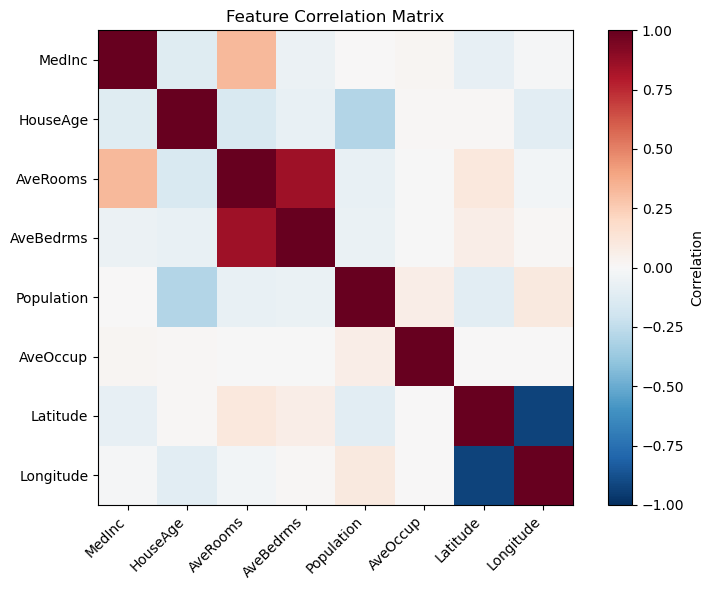

In [16]:
# Plot a correlation matrix to see which features are correlated
# This motivates WHY regularization (especially Ridge) helps — correlated features
# make OLS coefficients unstable.

df = pd.DataFrame(X, columns=feature_names)
corr = df.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Look for pairs with correlation > 0.7 or < -0.7 — these will cause problems for OLS.

## Baseline Model

In [17]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# Train a basic LinearRegression model
linreg = LinearRegression()
linreg.fit(X_train,y_train)

# Compute predictions on train and test
p_train = linreg.predict(X_train)
p_test = linreg.predict(X_test)

# Compute RMSE and R² for both sets
rmse_train_baseline = np.sqrt(mean_squared_error(y_train, p_train))
rmse_test_baseline = np.sqrt(mean_squared_error(y_test, p_test))
r2_train_baseline = r2_score(y_train, p_train)
r2_test_baseline = r2_score(y_test, p_test)

# Print results
print("Baseline Linear Regression:")
print(f"Train RMSE: {rmse_train_baseline:.2f}, R²: {r2_train_baseline:.2f}")
print(f"Test  RMSE: {rmse_test_baseline:.2f}, R²: {r2_test_baseline:.2f}")

Baseline Linear Regression:
Train RMSE: 0.72, R²: 0.61
Test  RMSE: 0.75, R²: 0.58


In [18]:
# Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False) #quadratic features

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Print how many features you now have
print(f"Original features: {X_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

Original features: 8
Polynomial features: 44


In [19]:
# Ridge, Lasso, and ElasticNet need Standard Scaler - bigger scales get penalized harder
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

## Ridge Regression (L2 Reg)
- Method: L2 penalty in the Linear Regression model - shrinks coefficients towards zero, but never zero
- Weight (W) is squared
- Hyperparameters: Alpha for penalty strength (level of shrinkage)
- Purpose: Multicollinearity (correlated predictors)
- Struggles: Keeps all features

In [20]:
# Define alpha 
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# Create empty lists
ridge_train_rmses = []
ridge_test_rmses = []
results = []

# Loop Over Alpha
for alpha in alphas:
    ridge_used = Ridge(alpha=alpha)
    ridge_used.fit(X_train_scaled, y_train)

    p_train = ridge_used.predict(X_train_scaled)
    p_test = ridge_used.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train,p_train))
    rmse_test = np.sqrt(mean_squared_error(y_test,p_test))
    gap = (rmse_train-rmse_test)

    ridge_train_rmses.append(rmse_train)
    ridge_test_rmses.append(rmse_test)
    
    results.append({
        'Alpha': alpha,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test,
        'Gap': gap  
    })
    pass

# Print Results 
results_df = pd.DataFrame(results)
display(results_df)

# Save the best model
best_idx_ridge = np.argmin(ridge_test_rmses) #Returns the index of the smallest value in a list
best_ridge_alpha = alphas[best_idx_ridge] #Selects the value of Alpha based on previous index
best_ridge = Ridge(alpha=best_ridge_alpha) 
best_ridge.fit(X_train_scaled, y_train)

rmse_train_ridge = ridge_train_rmses[best_idx_ridge] # Storing the RMSE score based on previous index
rmse_test_ridge =ridge_test_rmses[best_idx_ridge]

# Print Results ==============================================
print(f"\nBest Ridge: alpha={best_ridge_alpha}")
print(f"Test RMSE: {ridge_test_rmses[best_idx_ridge]:.2f}")
print(f'Train RMSE: {rmse_train_ridge:.2f}')
print(f'Test RMSE: {rmse_test_ridge:.2f}')
print(f'Zero: {gap}')

,Alpha,Train RMSE,Test RMSE,Gap
0,0.001,0.648646,0.677738,-0.029092
1,0.010,0.649221,0.660992,-0.011771
2,0.100,0.653976,0.667533,-0.013558
3,1.000,0.664799,0.687665,-0.022866
4,10.000,0.676970,0.706375,-0.029405
5,100.000,0.692150,0.713338,-0.021187



Best Ridge: alpha=0.01
Test RMSE: 0.66
Train RMSE: 0.65
Test RMSE: 0.66
Zero: -0.02118745571999936


## Lasso Regression (L1 Reg)
- Method: L1 penalty in the Linear Regression model - shrinks coefficients to zero when needed
- Weight (W) is absolute value
- Hyperparameters: Alpha for penalty number (Amount of coefficients zeroed out)
- Purpose: Does feature selection through this process
- Struggles: Multiple features are correlated

In [21]:
# Define alpha
alphas_lasso = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

# Create empty lists 
lasso_train_rmses = []
lasso_test_rmses = []
lasso_n_zeros = []
results = []

# Loop over alphas 
for alpha in alphas_lasso:
    lasso_used = Lasso(alpha=alpha, max_iter = 50000)
    lasso_used.fit(X_train_scaled, y_train)

    p_train = lasso_used.predict(X_train_scaled)
    p_test = lasso_used.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train,p_train))
    rmse_test = np.sqrt(mean_squared_error(y_test,p_test))
    gap = (rmse_test-rmse_train)

    n_zeros = np.sum(lasso_used.coef_ == 0)
    n_nonzero = np.sum(lasso_used.coef_ != 0)

    lasso_train_rmses.append(rmse_train)
    lasso_test_rmses.append(rmse_test)
    lasso_n_zeros.append(n_zeros)

    results.append({
        'Alpha': alpha,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test,
        'Gap': gap,
        'Zeros': (f'{n_zeros}/44')
    })
    pass

# Print Results
results_df = pd.DataFrame(results)
display(results_df)

# Save the best model
best_idx_lasso = np.argmin(lasso_test_rmses)
best_lasso_alpha = alphas_lasso[best_idx_lasso]

best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=50000)
best_lasso.fit(X_train_scaled, y_train)

rmse_train_lasso = lasso_train_rmses[best_idx_lasso]
rmse_test_lasso =lasso_test_rmses[best_idx_lasso]

# Print Results 
print(f'Best Lasso:{best_lasso_alpha}')
print(rmse_train_lasso)
print(rmse_test_lasso)
print(f"Zeroed out {np.sum(best_lasso.coef_ == 0)} of {len(best_lasso.coef_)} coefficients") # Info is created after the fitted model

,Alpha,Train RMSE,Test RMSE,Gap,Zeros
0,0.001,0.684742,0.695292,0.010550,17/44
1,0.010,0.718374,0.749320,0.030946,28/44
2,0.050,0.774841,0.783052,0.008211,38/44
3,0.100,0.812049,0.818160,0.006112,41/44
4,0.500,0.973091,0.968460,-0.004631,43/44
5,1.000,1.156191,1.144856,-0.011335,44/44


Best Lasso:0.001
0.6847421609898482
0.6952918795740561
Zeroed out 17 of 44 coefficients


## ElasticNet (Both Ridge and Lasso)
- Method: Combines benefits from Lasso's feature selection with Ridge's multicollinearity
- Hyperparameters: Alpha for strength and l1 for the ratio between Lasso and Ridge involvement
- Struggles: More complex from a design and interpreting perspective

In [22]:
# Define parameter grids 
alphas_en = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# Create containers and starting value 
best_rmse = 999
best_params = {}
results = []

# Note: parameters need to be the exact wording (alphas != alpha & l1 != l1_ratio)
# loop between parameters 
for alpha in alphas_en:
    for l1 in l1_ratios:
        elastic_net = ElasticNet(alpha = alpha, 
                                 l1_ratio = l1, 
                                 max_iter=50000) # Had to increase due to reach max_iter before completion
        elastic_net.fit(X_train_scaled, y_train)

        p_train = elastic_net.predict(X_train_scaled)
        p_test = elastic_net.predict(X_test_scaled)
        
        rmse_train = np.sqrt(mean_squared_error(y_train,p_train))
        rmse_test = np.sqrt(mean_squared_error(y_test,p_test))
        gap = (rmse_test-rmse_train)
        
        n_zeros = np.sum(elastic_net.coef_ == 0)
        n_nonzero = np.sum(elastic_net.coef_ != 0)

        results.append({ # Additional parts was added for my personal investigation and knowledge.
            'alpha': alpha,
            'l1': l1,
            'train_rmse': rmse_train,
            'test_rmse': rmse_test,
            'gap': gap,
            'zeros': n_zeros    
        })

        if rmse_test < best_rmse: # Used to determine best possible alpha and l1_ratio and then stores it into 'best_params'
            best_rmse = rmse_test
            best_params = {'alpha': alpha, 'l1': l1}
        pass

# Print Table 
df_results = pd.DataFrame(results)
display(df_results)

# Print best parameters 
print(f"Best ElasticNet: alpha={best_params['alpha']}, l1_ratio={best_params['l1']}")
print(f"Test RMSE: {best_rmse:.2f}")

# Refit best model and save it 
best_en = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1'], max_iter=50000)
best_en.fit(X_train_scaled, y_train)

p_train = best_en.predict(X_train_scaled)
p_test = best_en.predict(X_test_scaled)
        
rmse_train_en = np.sqrt(mean_squared_error(y_train,p_train))
rmse_test_en = np.sqrt(mean_squared_error(y_test,p_test))
gap = (rmse_test_en-rmse_train_en)

# Print Results
print(f'Best Parameterds:{best_params}')
print(f'Train RMSE: {rmse_train_en:.2f}')
print(f'Test RMSE: {rmse_test_en:.2f}')
print(f'Zero:{gap}')

,alpha,l1,train_rmse,test_rmse,gap,zeros
0,0.001,0.1,0.680406,0.711217,0.030812,0
1,0.001,0.3,0.681128,0.706176,0.025048,5
2,0.001,0.5,0.681863,0.701173,0.019310,6
3,0.001,0.7,0.682689,0.697175,0.014486,10
4,0.001,0.9,0.684357,0.695368,0.011011,13
5,0.010,0.1,0.698676,0.709921,0.011245,3
6,0.010,0.3,0.705728,0.721689,0.015961,10
7,0.010,0.5,0.712294,0.749180,0.036886,21
8,0.010,0.7,0.714540,0.749635,0.035095,24
9,0.010,0.9,0.716872,0.749257,0.032385,25


Best ElasticNet: alpha=0.001, l1_ratio=0.9
Test RMSE: 0.70
Best Parameterds:{'alpha': 0.001, 'l1': 0.9}
Train RMSE: 0.68
Test RMSE: 0.70
Zero:0.011011174507195132


## Random Forest
- Method: Combination of decision trees with the final prediction the average of all trees.
- Hyperparameters: n_estimators, max_depth, min_samples_split
- Pros: Captures non-linear relationships, a robust model, no need for scaling data as it can handle mixed data well
- Cons: More complex in terms of tuning hyperparameters and in interpretability

In [23]:
# Random Forest does not need Standard Scaler for prediction.

# Train Random Forest 
RanFor = RandomForestRegressor(n_estimators = 100, # Number of decision trees
                               max_depth = 5, # Max depth of each tree - controls complexity to avoid overfitting
                               min_samples_split = 10, # Smallest number required to split a node into another tree
                               random_state = 42, n_jobs = -1) # n_jobs=-1 uses all CPU cores (speeds up training ~2-3x)
# Fit Model
RanFor.fit(X_train, y_train)

# Predict Train and Test
p_train = RanFor.predict(X_train)
p_test = RanFor.predict(X_test)

# Measure RMSE for Train and Test
rmse_train_ranfor = np.sqrt(mean_squared_error(y_train, p_train))
rmse_test_ranfor = np.sqrt(mean_squared_error(y_test, p_test))

# Print results
print(f"Train RMSE: {rmse_train_ranfor:.2f}")
print(f"Test  RMSE: {rmse_test_ranfor:.2f}")
print(f"Gap: {rmse_test_ranfor - rmse_train_ranfor:.2f}")

Train RMSE: 0.65
Test  RMSE: 0.68
Gap: 0.03


In [24]:
# Define Values
n_estimators = [10, 50, 100]
max_depth = [2,3,4,5]
min_samples_split = [5,10]

# Create empyt lists
best_rmse = 999
best_params = {}
results = []

# loop between parameters 
for n_estimator in n_estimators:
    for max_dep in max_depth:
        for min_split in min_samples_split:
            RanFor = RandomForestRegressor(n_estimators = n_estimator, max_depth = max_dep, min_samples_split = min_split, random_state=42, n_jobs = -1)
            RanFor.fit(X_train, y_train)

            p_train = RanFor.predict(X_train)
            p_test = RanFor.predict(X_test)
                        
            rmse_train_ranfor = np.sqrt(mean_squared_error(y_train, p_train))
            rmse_test_ranfor = np.sqrt(mean_squared_error(y_test, p_test))
            gap = (rmse_test_ranfor-rmse_train_ranfor)

            results.append({ 
            'n_estimators': n_estimator,
            'max_depth': max_dep,
            'min_samples_split': min_split,
            'train_rmse': rmse_train_ranfor,
            'test_rmse': rmse_test_ranfor,
            'gap': gap,
        })

            if rmse_test_ranfor < best_rmse: 
                    best_rmse = rmse_test_ranfor
                    best_params = {'n_estimators': n_estimator , 'max_depth': max_dep, 'min_samples_split': min_split}
            pass

# Print Table 
df_results = pd.DataFrame(results)
display(df_results)

# Print best parameters 
print(f'Best Random Forest Regressor: n_estimators={best_params['n_estimators']}, max_depth={best_params['max_depth']}, min_samples_split={best_params['min_samples_split']}')
print(f"Test RMSE: {best_rmse:.2f}")

# Refit best model and save it 
RanFor = RandomForestRegressor(n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], min_samples_split=best_params['min_samples_split'], n_jobs = -1)
RanFor.fit(X_train, y_train)

p_train = RanFor.predict(X_train)
p_test = RanFor.predict(X_test)
        
rmse_train_rf = np.sqrt(mean_squared_error(y_train,p_train))
rmse_test_rf = np.sqrt(mean_squared_error(y_test,p_test))
gap = (rmse_test_rf-rmse_train_rf)

# Print Results
print(f'Best Parameterds: {best_params}')
print(f'Train RMSE: {rmse_train_rf:.2f}')
print(f'Test RMSE: {rmse_test_rf:.2f}')
print(f'Zero: {gap}')

,n_estimators,max_depth,min_samples_split,train_rmse,test_rmse,gap
0,10,2,5,0.844933,0.858772,0.013839
1,10,2,10,0.844933,0.858772,0.013839
2,10,3,5,0.764556,0.780897,0.016341
3,10,3,10,0.764556,0.780897,0.016341
4,10,4,5,0.708922,0.730000,0.021078
5,10,4,10,0.708984,0.729921,0.020937
6,10,5,5,0.658546,0.688171,0.029625
7,10,5,10,0.658642,0.688095,0.029453
8,50,2,5,0.844644,0.858224,0.013581
9,50,2,10,0.844644,0.858224,0.013581


Best Random Forest Regressor: n_estimators=50, max_depth=5, min_samples_split=5
Test RMSE: 0.68
Best Parameterds: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 5}
Train RMSE: 0.65
Test RMSE: 0.68
Zero: 0.028403829080377196


## Comparison

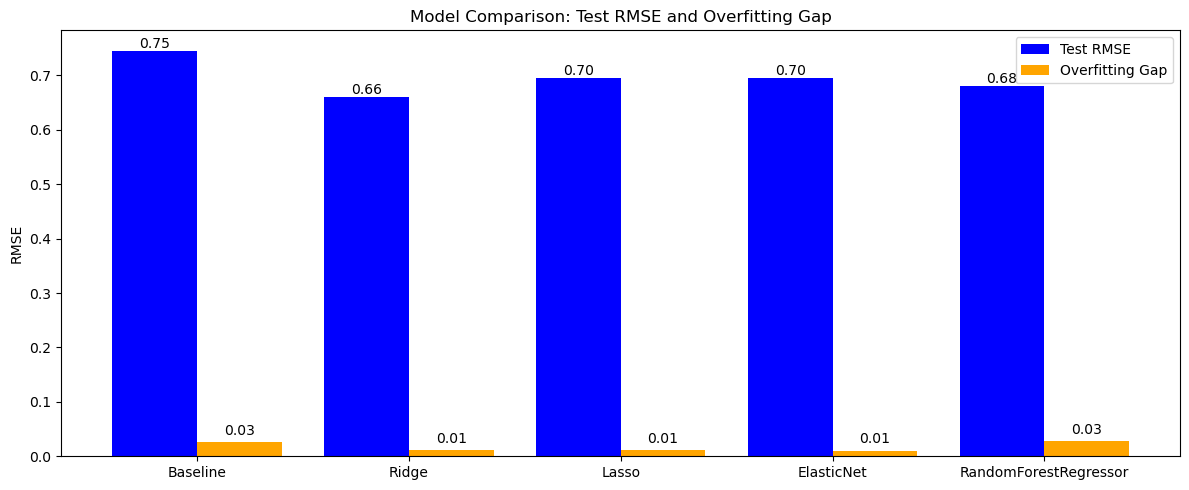

In [32]:
#Create a grouped bar chart showing Test RMSE AND the Gap for each model
model_names = ['Baseline', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForestRegressor']
test_rmses = [rmse_test_baseline, rmse_test_ridge, rmse_test_lasso, rmse_test_en, rmse_test_rf]
gaps = [rmse_test_baseline - rmse_train_baseline,
        rmse_test_en - rmse_train_en,
        rmse_test_ridge - rmse_train_ridge,
        rmse_test_lasso - rmse_train_lasso,
        rmse_test_rf - rmse_train_rf]

# Code for visual was copied from assignment with minor edits
x = np.arange(len(model_names))
width = 0.40 # Made width larger to fill in white space

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, test_rmses, width, label='Test RMSE', color=['blue'])
bars2 = ax.bar(x + width/2, gaps, width, label='Overfitting Gap', color=['orange'])

ax.bar_label(bars1, fmt='%.2f', padding=0) # AI used to explain 'padding': Spacing between number and bar
ax.bar_label(bars2, fmt='%.2f', padding=0)

ax.set_ylabel('RMSE')
ax.set_title('Model Comparison: Test RMSE and Overfitting Gap')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
plt.tight_layout()
plt.show()